In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
print("All good:", pd.__version__, np.__version__, xgb.__version__)

All good: 3.0.5 2.4.6 3.2.0


In [5]:
import pandas as pd

df = pd.read_csv('../data/household_power_consumption.txt', sep=';', 
                  na_values=['?'], low_memory=False)

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('datetime', inplace=True)

print(df.shape)
print(df.head())
print(df.isna().sum())

(2075259, 7)
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28

In [6]:
# Handle missing values - forward fill is reasonable for short gaps in time series
df = df.ffill()

# Confirm no NaNs remain
print("Remaining NaNs:", df.isna().sum().sum())

# Resample to daily - sum for power-related columns makes sense for "daily consumption"
daily_df = df['Global_active_power'].resample('D').sum()

print(daily_df.shape)
print(daily_df.head())
print(daily_df.describe())

Remaining NaNs: 0
(1442,)
datetime
2006-12-16    1209.176
2006-12-17    3390.460
2006-12-18    2203.826
2006-12-19    1666.194
2006-12-20    2225.748
Freq: D, Name: Global_active_power, dtype: float64
count    1442.000000
mean     1563.162724
std       603.833832
min       210.240000
25%      1166.661500
50%      1542.486000
75%      1893.959000
max      4773.386000
Name: Global_active_power, dtype: float64


In [7]:
import pandas as pd

# Convert to DataFrame so we can add feature columns
data = daily_df.to_frame(name='consumption')

# Calendar-based features
data['day_of_week'] = data.index.dayofweek      # 0=Monday, 6=Sunday
data['month'] = data.index.month
data['day_of_year'] = data.index.dayofyear
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

# Lag features - yesterday's and last week's consumption help predict today's
data['lag_1'] = data['consumption'].shift(1)
data['lag_7'] = data['consumption'].shift(7)

# Rolling average - smoothed recent trend
data['rolling_mean_7'] = data['consumption'].shift(1).rolling(window=7).mean()

# Drop rows with NaN created by lag/rolling features (first ~7 days)
data = data.dropna()

print(data.shape)
print(data.head())

(1435, 8)
            consumption  day_of_week  month  day_of_year  is_weekend  \
datetime                                                               
2006-12-23     4773.386            5     12          357           1   
2006-12-24     2550.012            6     12          358           1   
2006-12-25     2743.120            0     12          359           0   
2006-12-26     3934.110            1     12          360           0   
2006-12-27     1528.760            2     12          361           0   

               lag_1     lag_7  rolling_mean_7  
datetime                                        
2006-12-23  2341.338  1209.176     2107.693429  
2006-12-24  4773.386  3390.460     2616.866286  
2006-12-25  2550.012  2203.826     2496.802286  
2006-12-26  2743.120  1666.194     2573.844286  
2006-12-27  3934.110  2225.748     2897.832286  


In [8]:
from sklearn.model_selection import train_test_split

# Define features and target
feature_cols = ['day_of_week', 'month', 'day_of_year', 'is_weekend', 'lag_1', 'lag_7', 'rolling_mean_7']
X = data[feature_cols]
y = data['consumption']

# Chronological split - last 20% of days as test set (no shuffling!)
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train date range:", X_train.index.min(), "to", X_train.index.max())
print("Test date range:", X_test.index.min(), "to", X_test.index.max())

Train size: (1148, 7)
Test size: (287, 7)
Train date range: 2006-12-23 00:00:00 to 2010-02-12 00:00:00
Test date range: 2010-02-13 00:00:00 to 2010-11-26 00:00:00


In [9]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Mean of actual test values: {y_test.mean():.2f}")

MAE: 251.70
RMSE: 348.52
Mean of actual test values: 1422.91


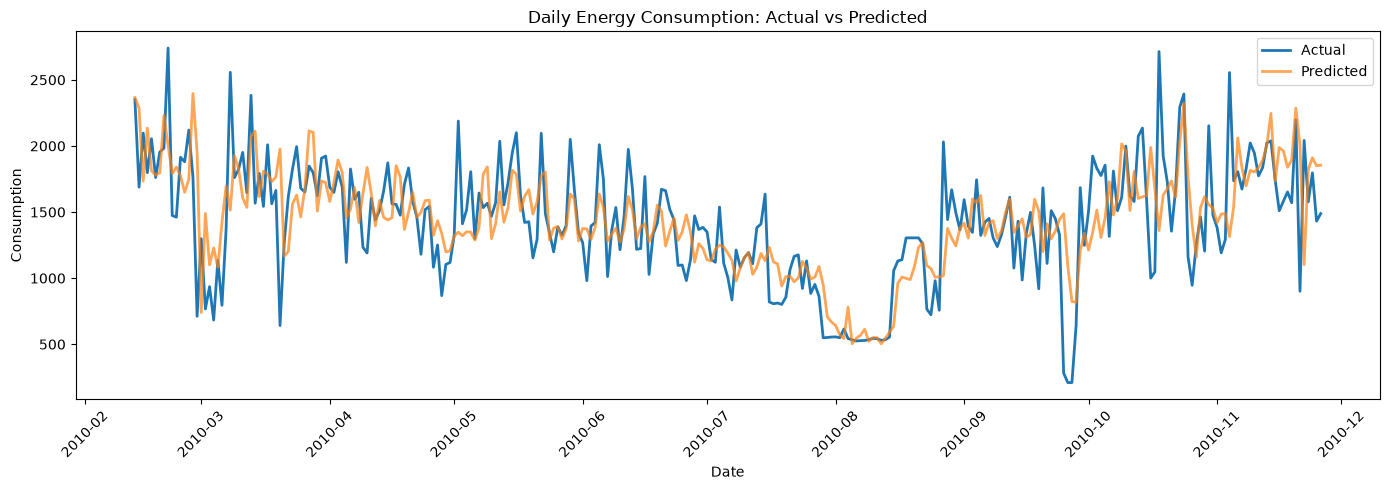

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Actual', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted', linewidth=2, alpha=0.7)
plt.title('Daily Energy Consumption: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Consumption')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 48.778,
    "longitude": 2.290,
    "start_date": "2006-12-16",
    "end_date": "2010-11-26",
    "daily": ["temperature_2m_mean", "temperature_2m_min", "temperature_2m_max"],
    "timezone": "Europe/Paris"
}

response = requests.get(url, params=params)
weather_json = response.json()

weather_df = pd.DataFrame(weather_json['daily'])
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df.set_index('time', inplace=True)

print(weather_df.shape)
print(weather_df.head())

(1442, 3)
            temperature_2m_mean  temperature_2m_min  temperature_2m_max
time                                                                   
2006-12-16                  6.2                 4.2                 8.4
2006-12-17                  2.9                -0.2                 7.0
2006-12-18                  3.1                 1.1                 5.2
2006-12-19                  1.7                 0.6                 4.2
2006-12-20                  1.1                -0.9                 4.7


In [12]:
# Merge weather data with our feature-engineered dataset
data = data.join(weather_df, how='left')

print(data.shape)
print(data.isna().sum())
print(data.head())

(1435, 11)
consumption            0
day_of_week            0
month                  0
day_of_year            0
is_weekend             0
lag_1                  0
lag_7                  0
rolling_mean_7         0
temperature_2m_mean    0
temperature_2m_min     0
temperature_2m_max     0
dtype: int64
            consumption  day_of_week  month  day_of_year  is_weekend  \
datetime                                                               
2006-12-23     4773.386            5     12          357           1   
2006-12-24     2550.012            6     12          358           1   
2006-12-25     2743.120            0     12          359           0   
2006-12-26     3934.110            1     12          360           0   
2006-12-27     1528.760            2     12          361           0   

               lag_1     lag_7  rolling_mean_7  temperature_2m_mean  \
datetime                                                              
2006-12-23  2341.338  1209.176     2107.693429        

In [13]:
from sklearn.model_selection import train_test_split

# Updated feature list including weather
feature_cols = ['day_of_week', 'month', 'day_of_year', 'is_weekend', 
                'lag_1', 'lag_7', 'rolling_mean_7',
                'temperature_2m_mean', 'temperature_2m_min', 'temperature_2m_max']

X = data[feature_cols]
y = data['consumption']

# Same chronological split as before
split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1148, 10)
Test size: (287, 10)


In [14]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model_weather = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model_weather.fit(X_train, y_train)
y_pred_weather = model_weather.predict(X_test)

mae_weather = mean_absolute_error(y_test, y_pred_weather)
rmse_weather = np.sqrt(mean_squared_error(y_test, y_pred_weather))

print(f"MAE (with weather): {mae_weather:.2f}")
print(f"RMSE (with weather): {rmse_weather:.2f}")
print(f"\nPrevious MAE (no weather): 251.70")
print(f"Previous RMSE (no weather): 348.52")

MAE (with weather): 256.95
RMSE (with weather): 358.93

Previous MAE (no weather): 251.70
Previous RMSE (no weather): 348.52


In [15]:
importances = pd.Series(model_weather.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

rolling_mean_7         0.407556
temperature_2m_max     0.155563
lag_1                  0.121778
day_of_week            0.091863
temperature_2m_mean    0.056635
day_of_year            0.048059
temperature_2m_min     0.047206
lag_7                  0.044112
month                  0.027229
is_weekend             0.000000
dtype: float32


In [16]:
# Heating degree feature - captures "how much colder than comfortable" 
# Higher value = more heating needed = likely higher consumption
data['heating_degree'] = (18 - data['temperature_2m_mean']).clip(lower=0)

feature_cols_v2 = ['day_of_week', 'month', 'day_of_year', 
                    'lag_1', 'lag_7', 'rolling_mean_7',
                    'temperature_2m_max', 'heating_degree']

X = data[feature_cols_v2]
y = data['consumption']

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model_v2 = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model_v2.fit(X_train, y_train)
y_pred_v2 = model_v2.predict(X_test)

mae_v2 = mean_absolute_error(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))

print(f"MAE (v2 - lean weather features): {mae_v2:.2f}")
print(f"RMSE (v2 - lean weather features): {rmse_v2:.2f}")
print(f"\nBaseline (no weather):        MAE 251.70 | RMSE 348.52")
print(f"All weather cols:              MAE 256.95 | RMSE 358.93")

MAE (v2 - lean weather features): 250.00
RMSE (v2 - lean weather features): 352.47

Baseline (no weather):        MAE 251.70 | RMSE 348.52
All weather cols:              MAE 256.95 | RMSE 358.93


In [17]:
# Additional lag and rolling features
data['lag_2'] = data['consumption'].shift(2)
data['lag_3'] = data['consumption'].shift(3)
data['rolling_std_7'] = data['consumption'].shift(1).rolling(window=7).std()
data['rolling_mean_14'] = data['consumption'].shift(1).rolling(window=14).mean()

data = data.dropna()

feature_cols_v3 = ['day_of_week', 'month', 'day_of_year', 
                    'lag_1', 'lag_2', 'lag_3', 'lag_7', 
                    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7',
                    'temperature_2m_max', 'heating_degree']

X = data[feature_cols_v3]
y = data['consumption']

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

model_v3 = xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
model_v3.fit(X_train, y_train)
y_pred_v3 = model_v3.predict(X_test)

mae_v3 = mean_absolute_error(y_test, y_pred_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test, y_pred_v3))

print(f"MAE (v3 - richer lags + weather): {mae_v3:.2f}")
print(f"RMSE (v3 - richer lags + weather): {rmse_v3:.2f}")
print(f"\nBaseline (no weather):     MAE 251.70 | RMSE 348.52")
print(f"v2 (lean weather):          MAE 250.00 | RMSE 352.47")

MAE (v3 - richer lags + weather): 249.04
RMSE (v3 - richer lags + weather): 347.68

Baseline (no weather):     MAE 251.70 | RMSE 348.52
v2 (lean weather):          MAE 250.00 | RMSE 352.47


In [18]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

# TimeSeriesSplit respects chronological order within cross-validation folds
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV MAE: 309.866904536107


In [19]:
best_params = search.best_params_

model_tuned = xgb.XGBRegressor(**best_params, random_state=42)
model_tuned.fit(X_train, y_train)
y_pred_tuned = model_tuned.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"MAE (tuned): {mae_tuned:.2f}")
print(f"RMSE (tuned): {rmse_tuned:.2f}")
print(f"\nPrevious best (v3, untuned): MAE 249.04 | RMSE 347.68")

MAE (tuned): 247.80
RMSE (tuned): 338.54

Previous best (v3, untuned): MAE 249.04 | RMSE 347.68


In [20]:
# Naive baseline 1: "tomorrow = today" (using lag_1)
naive_lag1_pred = X_test['lag_1']
mae_naive1 = mean_absolute_error(y_test, naive_lag1_pred)
rmse_naive1 = np.sqrt(mean_squared_error(y_test, naive_lag1_pred))

# Naive baseline 2: "tomorrow = same day last week" (using lag_7)
naive_lag7_pred = X_test['lag_7']
mae_naive7 = mean_absolute_error(y_test, naive_lag7_pred)
rmse_naive7 = np.sqrt(mean_squared_error(y_test, naive_lag7_pred))

print("Naive (yesterday's value):")
print(f"  MAE: {mae_naive1:.2f} | RMSE: {rmse_naive1:.2f}")
print("\nNaive (same day last week):")
print(f"  MAE: {mae_naive7:.2f} | RMSE: {rmse_naive7:.2f}")
print(f"\nTuned XGBoost model:")
print(f"  MAE: {mae_tuned:.2f} | RMSE: {rmse_tuned:.2f}")

Naive (yesterday's value):
  MAE: 286.29 | RMSE: 405.35

Naive (same day last week):
  MAE: 387.99 | RMSE: 532.19

Tuned XGBoost model:
  MAE: 247.80 | RMSE: 338.54


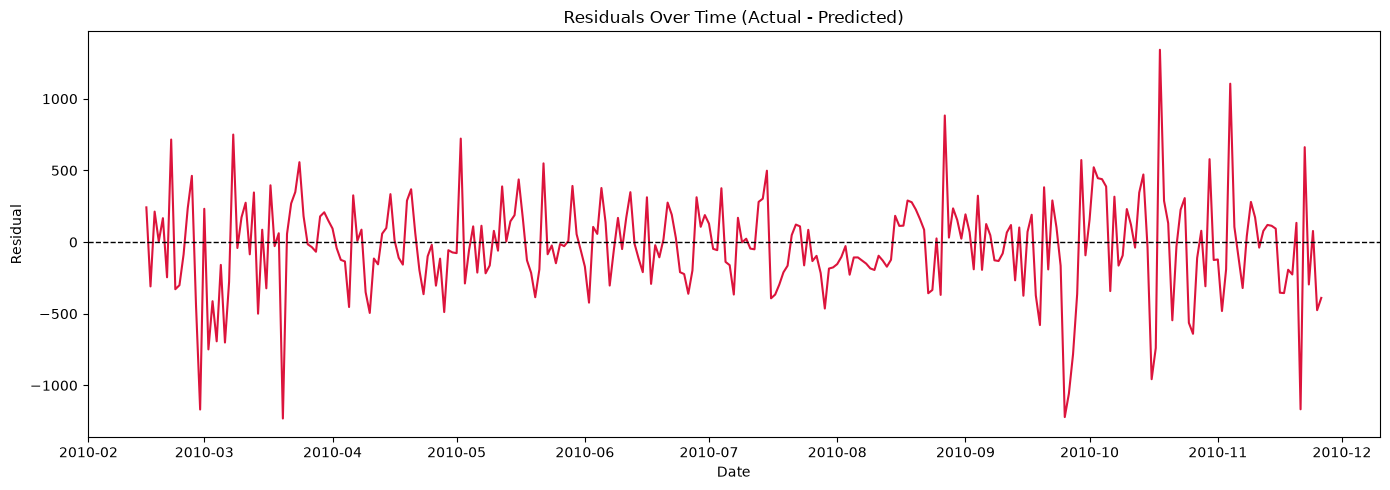

Residual stats:
  Mean: -28.99 (should be near 0 - no systematic bias)
  Std: 337.29
  Max overprediction: -1231.24
  Max underprediction: 1341.95


In [21]:
residuals = y_test.values - y_pred_tuned

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, residuals, color='crimson')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals Over Time (Actual - Predicted)')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

print("Residual stats:")
print(f"  Mean: {residuals.mean():.2f} (should be near 0 - no systematic bias)")
print(f"  Std: {residuals.std():.2f}")
print(f"  Max overprediction: {residuals.min():.2f}")
print(f"  Max underprediction: {residuals.max():.2f}")

In [22]:
# Identify the largest error days
worst_days = pd.Series(residuals, index=y_test.index).abs().sort_values(ascending=False).head(10)
print("Days with largest prediction errors:")
print(worst_days)

Days with largest prediction errors:
datetime
2010-10-18    1341.946866
2010-03-20    1231.235408
2010-09-25    1221.188149
2010-02-28    1168.472550
2010-11-21    1166.915439
2010-11-04    1105.223515
2010-09-26    1056.890005
2010-10-16     957.019691
2010-08-27     883.312720
2010-09-27     783.238027
dtype: float64


In [23]:
# Re-aggregate sub-metering to daily level from the original df (before we dropped these columns)
daily_submeter = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('D').sum()

worst_dates = worst_days.index

print("Sub-metering on worst-error days vs typical values:\n")
print("Typical (median) daily values:")
print(daily_submeter.median())
print("\nValues on worst-error days:")
print(daily_submeter.loc[worst_dates])

Sub-metering on worst-error days vs typical values:

Typical (median) daily values:
Sub_metering_1    1110.5
Sub_metering_2     682.5
Sub_metering_3    9262.5
dtype: float64

Values on worst-error days:
            Sub_metering_1  Sub_metering_2  Sub_metering_3
datetime                                                  
2010-10-18          2234.0         10218.0         16382.0
2010-03-20             0.0          1233.0          2177.0
2010-09-25             0.0           150.0          2100.0
2010-02-28             0.0           487.0          2952.0
2010-11-21             0.0           506.0          4778.0
2010-11-04          6029.0         11193.0         10286.0
2010-09-26             0.0             0.0          1440.0
2010-10-16             0.0           645.0          7656.0
2010-08-27           930.0          7583.0         12707.0
2010-09-27             0.0             0.0          1440.0


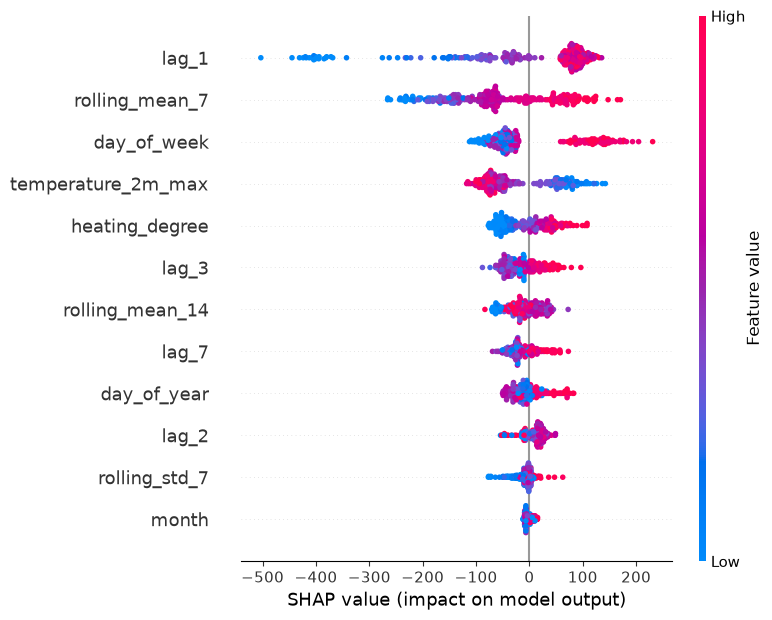

In [25]:
import shap
explainer = shap.TreeExplainer(model_tuned)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [26]:
data.groupby('day_of_week')['consumption'].mean().round(1)

day_of_week
0    1413.1
1    1525.6
2    1561.5
3    1400.0
4    1482.3
5    1749.1
6    1712.0
Name: consumption, dtype: float64

In [27]:
# Get predictions on full test set (already have y_pred_tuned)
test_results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred_tuned
}, index=y_test.index)

# Define "high-usage day" threshold using training data's 90th percentile
high_usage_threshold = y_train.quantile(0.90)
print(f"High-usage threshold (90th percentile of training data): {high_usage_threshold:.2f}")

test_results['predicted_high_usage'] = test_results['predicted'] > high_usage_threshold
test_results['actual_high_usage'] = test_results['actual'] > high_usage_threshold

print(test_results.head(10))

High-usage threshold (90th percentile of training data): 2336.11
              actual    predicted  predicted_high_usage  actual_high_usage
datetime                                                                  
2010-02-15  2097.132  1854.933105                 False              False
2010-02-16  1797.756  2107.262939                 False              False
2010-02-17  2054.560  1841.913330                 False              False
2010-02-18  1761.156  1756.054688                 False              False
2010-02-19  1953.572  1786.733276                 False              False
2010-02-20  1983.728  2229.513184                 False              False
2010-02-21  2740.314  2024.823242                 False               True
2010-02-22  1474.036  1803.198975                 False              False
2010-02-23  1461.280  1762.138306                 False              False
2010-02-24  1914.278  2000.423218                 False              False


In [28]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

precision = precision_score(test_results['actual_high_usage'], test_results['predicted_high_usage'])
recall = recall_score(test_results['actual_high_usage'], test_results['predicted_high_usage'])

print(f"Precision: {precision:.2f} (of days flagged as high-usage, how many actually were)")
print(f"Recall: {recall:.2f} (of actual high-usage days, how many did we catch)")
print("\nConfusion Matrix:")
print(confusion_matrix(test_results['actual_high_usage'], test_results['predicted_high_usage']))

Precision: 0.00 (of days flagged as high-usage, how many actually were)
Recall: 0.00 (of actual high-usage days, how many did we catch)

Confusion Matrix:
[[279   0]
 [  6   0]]


d:\Energy-prediction\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
# Relative threshold: flag days where predicted value is in the top 10% 
# of the model's own predictions (not the absolute historical threshold)
predicted_threshold = test_results['predicted'].quantile(0.90)
print(f"Predicted-based threshold (90th percentile of predictions): {predicted_threshold:.2f}")

test_results['predicted_high_usage_v2'] = test_results['predicted'] > predicted_threshold

precision_v2 = precision_score(test_results['actual_high_usage'], test_results['predicted_high_usage_v2'])
recall_v2 = recall_score(test_results['actual_high_usage'], test_results['predicted_high_usage_v2'])

print(f"Precision: {precision_v2:.2f}")
print(f"Recall: {recall_v2:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(test_results['actual_high_usage'], test_results['predicted_high_usage_v2']))

Predicted-based threshold (90th percentile of predictions): 1851.06
Precision: 0.10
Recall: 0.50

Confusion Matrix:
[[253  26]
 [  3   3]]


In [30]:
for pct in [0.80, 0.85, 0.90, 0.95]:
    thresh = test_results['predicted'].quantile(pct)
    flagged = test_results['predicted'] > thresh
    p = precision_score(test_results['actual_high_usage'], flagged, zero_division=0)
    r = recall_score(test_results['actual_high_usage'], flagged, zero_division=0)
    print(f"Percentile {pct}: threshold={thresh:.1f}, precision={p:.2f}, recall={r:.2f}, flagged_days={flagged.sum()}")

Percentile 0.8: threshold=1701.1, precision=0.07, recall=0.67, flagged_days=57
Percentile 0.85: threshold=1764.6, precision=0.09, recall=0.67, flagged_days=43
Percentile 0.9: threshold=1851.1, precision=0.10, recall=0.50, flagged_days=29
Percentile 0.95: threshold=1928.4, precision=0.20, recall=0.50, flagged_days=15


In [31]:
def generate_recommendation(row):
    if row['predicted_high_usage_v2']:
        if row['day_of_week'] if 'day_of_week' in row else None:
            pass
        return "Predicted high-usage day — consider shifting laundry/dishwasher use to off-peak hours."
    elif row.name.dayofweek >= 5:  # weekend
        return "Weekend — typically ~17% higher usage; minor load-shifting can help."
    else:
        return "Normal usage expected — no action needed."

test_results['recommendation'] = test_results.apply(generate_recommendation, axis=1)
print(test_results[test_results['predicted_high_usage_v2']].head())

              actual    predicted  predicted_high_usage  actual_high_usage  \
datetime                                                                     
2010-02-15  2097.132  1854.933105                 False              False   
2010-02-16  1797.756  2107.262939                 False              False   
2010-02-20  1983.728  2229.513184                 False              False   
2010-02-21  2740.314  2024.823242                 False               True   
2010-02-24  1914.278  2000.423218                 False              False   

            predicted_high_usage_v2  \
datetime                              
2010-02-15                     True   
2010-02-16                     True   
2010-02-20                     True   
2010-02-21                     True   
2010-02-24                     True   

                                               recommendation  
datetime                                                       
2010-02-15  Predicted high-usage day — consider shi

In [32]:
print(test_results['recommendation'].value_counts())

recommendation
Normal usage expected — no action needed.                                                 195
Weekend — typically ~17% higher usage; minor load-shifting can help.                       61
Predicted high-usage day — consider shifting laundry/dishwasher use to off-peak hours.     29
Name: count, dtype: int64


## Limitations

- **Single-household scope**: This model is trained on one household's consumption data (2006–2010). It captures patterns specific to this household's routines and would need retraining — or at minimum revalidation — to generalize to other homes, climates, or regions.

- **Occupancy is invisible to the model**: Error analysis showed that 8 of the 10 largest prediction errors correspond to occupancy anomalies — days the household was unusually empty (likely travel) or unusually active (guests, heavy simultaneous appliance use, confirmed via sub-metering data). No feature available here — calendar, weather, or historical consumption — can predict these in advance. This would require occupancy or calendar/booking data not present in this dataset, and is a fundamental data limitation rather than a modeling shortfall.

- **Weather adds real but modest value**: SHAP analysis confirmed a physically sensible effect — colder days increase predicted consumption via a heating-degree signal — but its magnitude was small relative to recent-consumption lag features (`lag_1`, `rolling_mean_7`). This explains why raw temperature alone did not meaningfully improve MAE/RMSE, and why an engineered heating-degree feature performed better than raw temperature values.

- **High-usage flagging involves a precision/recall tradeoff**: Only ~2% of days in this dataset are true high-usage days, making this a rare-event detection problem. At the chosen 85th-percentile threshold, the system catches ~67% of true high-usage days at ~9% precision. This deliberately favors recall (catching real spikes) over precision (minimizing false alarms) — a reasonable choice for a low-cost household advisory tool, but not appropriate for use cases where false alarms carry a real cost.

- **Limited historical range**: ~4 years of data restricts the model's ability to learn rare seasonal patterns (e.g., an unusually cold winter or a one-off heatwave) that may not have occurred during the training period.

In [33]:
model_tuned.save_model('../models/energy_model.json')

**Note on leakage**: All lag and rolling features use `.shift(1)` before computing rolling statistics, ensuring day N's features only use information available through day N-1. No future data leaks into any prediction.